# Technical Note P0: Scientific Python Ecosystem Map

**Wook Kang · Revised English edition · Version 1.0.0 · 3 October 2026**

This note connects a mathematical task to a numerical object, an implementation, and evidence about the result. It is an instructional computational document. Demonstration parameters are illustrative unless explicitly stated otherwise.

Run from a fresh kernel in cell order. See [the series README](../README.md) for setup and [editorial and verification notes](../docs/EDITORIAL_NOTES.md) for scope and limitations. The English prose has been reorganized and expanded from the supplied Korean notebook; this is an adapted edition rather than a line-by-line translation.

**Reading question:** What is given, what is unknown, what operation relates them, and what independent check can assess the output?

In [1]:
# Reproducible display and scale-aware comparison.
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
plt.rcParams.update({"figure.dpi": 110, "axes.grid": False})
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
def scaled_allclose(a, b, rtol=1e-12, atol=None, **kwargs):
    """Compare numerical examples using an absolute tolerance scaled to b."""
    a, b = np.asarray(a), np.asarray(b)
    scale = float(np.max(np.abs(b))) if b.size else 0.0
    if atol is None:
        atol = 1e-14 * max(scale, np.finfo(float).tiny)
    return np.allclose(a, b, rtol=rtol, atol=atol, **kwargs)


## 1. The ecosystem as a map

Begin with the mathematical task. Python expresses procedures, NumPy represents numerical objects, and SciPy supplies algorithms. Plotting and tabular tools help inspect and record results.

$$
\boxed{
\begin{array}{c}
\textbf{Python}\\
\downarrow\\
\textbf{NumPy}\\
\downarrow\\
\textbf{SciPy}\\
\downarrow\\
\textbf{Matplotlib / pandas / SymPy}\\
\downarrow\\
\textbf{Jupyter / testing / performance tools}
\end{array}
}
$$

| Layer | Main role |  
| --- | --- |  
| Python | Language, functions, control flow, objects, modules |  
| NumPy | Numerical representation of arrays, vectors, matrices, tensors, and fields |  
| SciPy | Linear algebra, optimization, integration, ODEs, interpolation, sparse solvers |  
| Matplotlib | Visualization of computational results |  
| pandas | Experimental and tabular data processing |  
| SymPy | symbolic algebra / calculus |  
| Jupyter | Code, explanation, and figures in one document |  
| testing / performance | Verification, profiling, acceleration |

## 2. Python is the language

Names, functions, control flow, modules, exceptions, and file handling organize the calculation. A constitutive law can be a callable; an algorithm receives that callable and evaluates it.

$$
f(x)=x^2+1
$$

In [2]:
def f(x):
    return x**2 + 1

print(f(3))

10


## 3. NumPy represents numerical objects

An ndarray stores homogeneous values with a shape and dtype. Vectors, matrices, and sampled fields share this container; their physical meaning comes from an explicit convention.

```python
numpy.ndarray
```

| Mathematical object | Example NumPy representation |  
| --- | --- |  
| scalar | `np.array(3.0)` or Python `float` |  
| vector | shape `(n,)` |  
| matrix | shape `(m,n)` |  
| 1D scalar field | shape `(Nx,)` |  
| 2D scalar field | shape `(Nx,Ny)` |  
| 3D scalar field | shape `(Nx,Ny,Nz)` |  
| 3D vector field | shape `(Nx,Ny,Nz,3)` |  
| 3D tensor field | shape `(Nx,Ny,Nz,3,3)` |

$$
\boxed{
\texttt{shape}
}
$$

In [3]:
import numpy as np

v = np.array([1.0, 2.0, 3.0])
A = np.array([[1.0, 2.0],
              [3.0, 4.0]])

U2 = np.zeros((20, 30))
V3 = np.zeros((20, 30, 10, 3))
T3 = np.zeros((20, 30, 10, 3, 3))

for name, obj in [
    ("vector", v),
    ("matrix", A),
    ("2D scalar field", U2),
    ("3D vector field", V3),
    ("3D tensor field", T3),
]:
    print(f"{name:18s} shape = {obj.shape}")

vector             shape = (3,)
matrix             shape = (2, 2)
2D scalar field    shape = (20, 30)
3D vector field    shape = (20, 30, 10, 3)
3D tensor field    shape = (20, 30, 10, 3, 3)


## 4. Shape and axis semantics

Record which axis denotes each coordinate or component. The same convention must govern slicing, differentiation, boundary indexing, flattening, and plotting.

```python
U.shape == (Nx, Ny, Nz)
```

$$
\boxed{
\text{array shape}
\leftrightarrow
\text{physical dimension}
}
$$

## 5. Choose SciPy by problem family

A linear system, root, minimum, initial-value problem, and integral require different interfaces. Identify the unknown, input, output, and stopping criterion before choosing a solver.

| Mathematical problem | SciPy |  
| --- | --- |  
| $Ax=b$ | `scipy.linalg`, `scipy.sparse.linalg` |  
| $f(x)=0$ | `scipy.optimize.root`, `root_scalar` |  
| $\min f(x)$ | `scipy.optimize.minimize` |  
| $\min \|r(\theta)\|^2$ | `scipy.optimize.least_squares` |  
| $\dot y=f(t,y)$ | `scipy.integrate.solve_ivp` |  
| $\int f(x)\,dx$ | `scipy.integrate` |  
| $f(x_i)\rightarrow f(x)$ | `scipy.interpolate` |  
| sparse matrix | `scipy.sparse` |  
| eigenvalue problem | `scipy.linalg`, `scipy.sparse.linalg` |

In [4]:
from scipy.optimize import root_scalar

# Example: solve x^2 - 2 = 0
sol = root_scalar(lambda x: x**2 - 2, bracket=[0, 2])
print("root =", sol.root)

root = 1.4142135623731364


## 6. NumPy and SciPy linear algebra

Dense solves are convenient for small systems. Large discretizations often need sparse storage, factorization reuse, or matrix-free products rather than an explicit dense matrix.

```python
np.linalg
```

$$
Ax=b
$$

In [5]:
A = np.array([[3.0, 1.0],
              [1.0, 2.0]])
b = np.array([9.0, 8.0])

x = np.linalg.solve(A, b)

print("x =", x)
print("residual =", A @ x - b)

x = [2. 3.]
residual = [0. 0.]


$$
\boxed{
\text{sparse matrix}
}
$$

## 7. Matplotlib as a diagnostic tool

Inspect fields, gradients, fluxes, residuals, convergence, and sensitivity. A smooth curve alone establishes neither numerical accuracy nor physical validity.

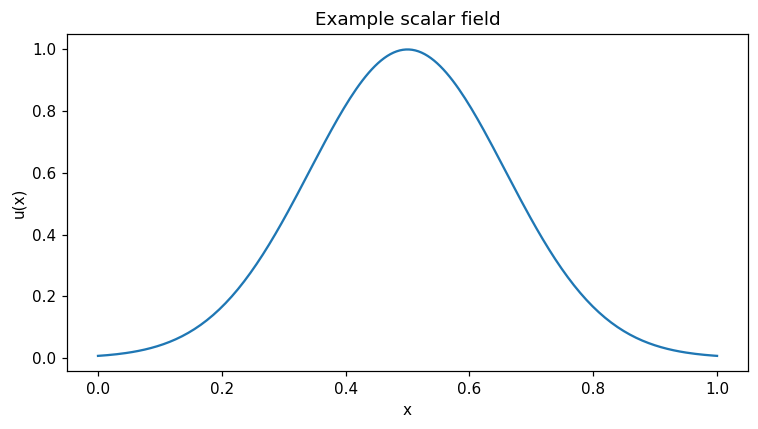

In [6]:
import matplotlib.pyplot as plt

x = np.linspace(0, 1, 200)
u = np.exp(-20*(x-0.5)**2)

plt.figure(figsize=(7, 4))
plt.plot(x, u)
plt.xlabel("x")
plt.ylabel("u(x)")
plt.title("Example scalar field")
plt.tight_layout()
plt.show()

## 8. pandas connects observations and calculations

A DataFrame associates values with named columns and index labels. Keep units and observation identifiers explicit; use arrays for numerical kernels and tables for experimental records.

```python
DataFrame
```

$$
\boxed{
\text{row-column table with labels}
}
$$

| time | moisture | temperature |  
| ---: | ---: | ---: |  
| 0 | 0.30 | 25 |  
| 1 | 0.28 | 30 |  
| 2 | 0.25 | 35 |

In [7]:
import pandas as pd

df = pd.DataFrame({
    "time_h": [0, 1, 2, 4, 8],
    "moisture": [0.30, 0.285, 0.270, 0.245, 0.210]
})

print(df)

   time_h  moisture
0       0     0.300
1       1     0.285
2       2     0.270
3       4     0.245
4       8     0.210


$$
\boxed{
\text{NumPy}
\rightarrow
\text{numerical array}
}
$$

$$
\boxed{
\text{pandas}
\rightarrow
\text{labeled tabular data}
}
$$

## 9. SymPy as the symbolic layer

Exact differentiation and algebra can help derive a Jacobian or check an equation. Symbolic simplification and floating-point computation are distinct operations.

$$
f(x)=x^3e^x
$$

In [8]:
import sympy as sp

x = sp.symbols("x")
f = x**3 * sp.exp(x)

print("f(x)  =", f)
print("f'(x) =", sp.diff(f, x))

f(x)  = x**3*exp(x)
f'(x) = x**3*exp(x) + 3*x**2*exp(x)


$$
\boxed{
\text{SymPy = symbolic}
\qquad
\text{NumPy/SciPy = numerical}
}
$$

## 10. Jupyter as a computational document

A notebook preserves explanation, equations, executable examples, and observed output together. Restart and run all cells to establish the actual dependency order.

## 11. Why there are many packages

Tools specialize in different objects and operations. Learn the common structure first, then introduce domain packages when the problem requires them.

$$
\boxed{
\text{Python}
+
\text{NumPy}
+
\text{SciPy}
+
\text{Matplotlib}
}
$$

## 12. Map the problem to an object and a tool

Ask what is given, what is unknown, and which operation connects them. This mapping is more useful than memorizing a catalogue of function names.

| Problem | Computational object | First tool to consider |  
| --- | --- | --- |  
| Scalar calculation | number | Python |  
| Vector or matrix calculation | ndarray | NumPy |  
| Field calculation | multidimensional ndarray | NumPy |  
| $Ax=b$ | matrix/vector | NumPy/SciPy |  
| sparse $Ax=b$ | sparse matrix | SciPy |  
| nonlinear $F(x)=0$ | residual function | SciPy |  
| ODE | state vector + RHS | SciPy |  
| least squares | residual vector | SciPy |  
| interpolation | sampled data | SciPy |  
| symbolic derivative | symbolic expression | SymPy |  
| experiment table | DataFrame | pandas |  
| plot | arrays | Matplotlib |

## 13. From a PDE to a numerical problem

Sampling creates a field array; discretization defines an operator, boundary conditions, and a state vector. The package executes this construction but does not choose the physical model.

$$
u(x,y,t)
$$

$$
u(x_i,y_j,t^n)
\rightarrow
U^n_{ij}
$$

```python
U[nx, ny]
```

$$
\nabla u
$$

$$
\mathbf q=-D\nabla u
$$

$$
\boxed{
\text{array}
+
\text{operator}
+
\text{solver}
}
$$

## 14. Reading order

Follow P1 through P13 after this overview. P5A is the short field introduction; P5B extends it with stencils and discrete operators. P6 includes the vectorization catalogue.

| TN | Title |  
| --- | --- |  
| P0 | Scientific Python Ecosystem Map |  
| P1 | Python Computational Grammar |  
| P2 | NumPy Array, Shape, Axis |  
| P3 | NumPy Indexing, Slicing, Broadcasting |  
| P4 | NumPy Vector, Matrix, Tensor Operations |  
| P5 | NumPy Fields and Grids |  
| P6 | NumPy Reshape, Stack, Einsum and Advanced Operations |  
| P7 | SciPy Linear Algebra |  
| P8 | SciPy Sparse Matrices and Sparse Solvers |  
| P9 | SciPy Nonlinear Equations and Root Finding |  
| P10 | SciPy ODE and Time Integration |  
| P11 | SciPy Optimization and Least Squares |  
| P12 | SciPy Interpolation, Integration, Numerical Differentiation |  
| P13 | Matplotlib, pandas, Verification Workflow |

## 15. Four ideas to retain

Python expresses procedure; NumPy represents numerical objects; SciPy selects algorithms by problem structure; verification checks what the computation actually establishes.

## 16. Check the environment

Report the interpreter and package versions used by the current kernel. A package installed in another environment is not necessarily available to this notebook.

In [9]:
import importlib

packages = [
    "numpy",
    "scipy",
    "matplotlib",
    "pandas",
    "sympy",
]

for name in packages:
    try:
        mod = importlib.import_module(name)
        print(f"{name:12s} {getattr(mod, '__version__', 'version unavailable')}")
    except Exception as e:
        print(f"{name:12s} NOT AVAILABLE ({e})")

numpy        2.3.5
scipy        1.17.0
matplotlib   3.10.8
pandas       2.2.3
sympy        1.14.0


## 17. Where this leads

For each new calculation, identify the mathematical object and numerical operation before choosing syntax. Continue with P1 for the computational grammar.

## Further work

1. Change one parameter or discretization choice and predict the effect before running.
2. Write the input and output shapes, units, and field locations.
3. Construct a deliberately invalid input and make the calculation report it clearly.
4. Separate an execution check from an accuracy check and from any physical claim.

## Primary documentation

- [Python language reference](https://docs.python.org/3/reference/)
- [NumPy user guide](https://numpy.org/doc/stable/user/)
- [SciPy user guide](https://docs.scipy.org/doc/scipy/tutorial/)
- [Matplotlib quick start](https://matplotlib.org/stable/users/explain/quick_start.html)
- [pandas user guide](https://pandas.pydata.org/docs/user_guide/)
- [SymPy documentation](https://docs.sympy.org/latest/index.html)

These are living documentation links. The accompanying requirements and verification report identify the versions actually executed for this edition.

## AI assistance and responsibility

The English adaptation, editorial supplementation, and code review were prepared with AI assistance. Wook Kang retains responsibility for reviewing the explanations, examples, and any subsequent research application. No new experimental validation is claimed.